In [1]:
# Foundational Package Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/200k.csv"
df = pd.read_csv(file_path)

In [ ]:
df.head()

In [ ]:
from sklearn.model_selection import train_test_split

# Veri setini %60 eğitim, %20 doğrulama ve %20 test olarak ayırma
train_size = 0.6
valid_size = 0.2
test_size = 0.2

# İlk olarak veri setini eğitim ve geri kalan (geçici) olarak ikiye ayırıyoruz
df_train, df_temp = train_test_split(df, test_size=(1 - train_size), random_state=42)

# Geri kalan (geçici) veri setini doğrulama ve test setlerine ayırıyoruz
df_valid, df_test = train_test_split(df_temp, test_size=test_size/(test_size + valid_size), random_state=42)

# Sonuçları kontrol edelim
print(f"Train set: {df_train.shape}")
print(f"Validation set: {df_valid.shape}")
print(f"Test set: {df_test.shape}")

In [ ]:
df.columns

In [ ]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts(ascending=True).plot.barh()
plt.title("Sınıfların Frekansları")
plt.show()

In [4]:
df_train.head(100)

NameError: name 'df_train' is not defined

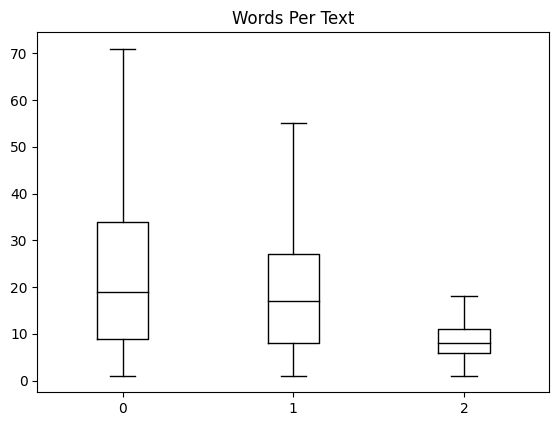

In [ ]:
# Bunu kullanma şimdilik

import pandas as pd

# NaN değerleri filtreleyerek Words Per Text sütununu oluşturma
df["Words Per Text"] = df["text"].dropna().str.split().apply(len)

# Boxplot'u çizme
df.boxplot("Words Per Text", by="sentiment", grid=False, showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()


In [6]:
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True))

NameError: name 'df' is not defined

In [ ]:
# Yinelenen satırların sayısını bul
yinelenen = df.duplicated().sum()
print(f"Yinelenen satırların sayısı: {yinelenen}")

# Null değer içeren satırları sil
df = df.dropna(how='any', axis=0)

# Yinelenen satırları sil
df = df.drop_duplicates()

# Yinelenen satırların sayısını tekrar bul
yinelenen2 = df.duplicated().sum()
print(f"Yinelenen satırların sayısı (temizlemeden sonra): {yinelenen2}")

Yinelenen satırların sayısı: 9482
Yinelenen satırların sayısı (temizlemeden sonra): 0


In [ ]:
print(df['sentiment'].value_counts())

sentiment
2    69971
1    67238
0    63307
Name: count, dtype: int64


In [ ]:
# Tüm metni küçük harfe dönüştürme
df['text'] = df['text'].str.lower()

In [ ]:
# Sınıf dengesizliği var mı diye sınıflaarı görme
df['sentiment'].value_counts(normalize = True)

sentiment
2    0.348955
1    0.335325
0    0.315720
Name: proportion, dtype: float64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200516 entries, 0 to 209999
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   sentiment  200516 non-null  int64 
 1   text       200516 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.6+ MB


In [ ]:
# Verilerin temiz olduğundan emin olun.
data = pd.read_csv('200k.csv')
data.isna().sum()

sentiment    0
text         5
dtype: int64

In [ ]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('We will use the GPU:', torch.cuda.get_device_name(0))

else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

We will use the GPU: Tesla T4


## Dataset Preprocessing

In [ ]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from transformers import AutoTokenizer

# NLTK kütüphanesini kullanarak Türkçe dilindeki etkisiz kelimeleri (stopwords) indiriyoruz.
nltk.download('stopwords')
stop_words_list = stopwords.words('turkish')

# Veri setindeki hatalı verilerin kaldırılması için bir dizi oluşturduk.
false_text = [chr(i) for i in range(97, 123)]

# Ön işleme adımlarını yapmak için fonksiyonumuzu tanımlıyoruz.
def preprocess_text(text):
    if isinstance(text, str):
        # Küçük harflere çevirme
        text = text.lower()
        # Satır sonu karakterlerini kaldırma
        text = re.sub(r'\n', ' ', text)
        # Rakamları kaldırma
        text = re.sub(r'\d', '', text)
        # Noktalama işaretlerini kaldırma
        text = text.translate(str.maketrans("", "", string.punctuation))
        # Stop-words'leri kaldırma
        words = text.split()
        words = [word for word in words if not word in stop_words_list]
        # Veri setindeki hatalı verilerin kaldırılması
        words = [word for word in words if not word in false_text]
        # Tekrarlanan karakterlerin kaldırılması
        words = [re.sub(r'(.)\1{1,}', r'\1\1', word) for word in words]
        # Tekrarlanan boşlukların kaldırılması
        words = [word.strip() for word in words if len(word.strip()) > 1]
        text = " ".join(words)
    return text

# Veriyi bir CSV dosyasından yüklemek
dataset_df = pd.read_csv('200k.csv')

# 'text' sütunundaki NaN değerleri boş string ile doldurma
if 'text' in dataset_df.columns:
    dataset_df['text'] = dataset_df['text'].fillna('')

# Ön işleme fonksiyonunu 'text' sütununa uygulama
if dataset_df is not None:
    dataset_df['text'] = dataset_df['text'].apply(preprocess_text)

# Tokenizer'ı yükleme
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")

# Metni BERT'e uygun hale getirmek için tokenize işlemi gerçekleştirir
def tokenize(text, tokenizer, max_seq_length):
    # Metni tokenize eder
    tokens = tokenizer.tokenize(text)
    # Özel belirteçler ekler: [CLS] başlangıç belirteci ve [SEP] bitiş belirteci
    tokens = ['[CLS]'] + tokens + ['[SEP]']
    # Tokenleri BERT'in anlayabileceği sayılara dönüştürür
    input_ids = tokenizer.convert_tokens_to_ids(tokens)
    # Giriş dizisi uzunluğunu belirler
    padding_length = max_seq_length - len(input_ids)
    # Eğer giriş dizisi maksimum uzunluktan kısa ise, sıfırlarla dolgu yapar
    input_ids += [0] * padding_length
    # Dikkat maskesini oluşturur: tokenize edilen kısımlar için 1, dolgu için 0
    attention_mask = [1] * len(input_ids) + [0] * padding_length
    return input_ids, attention_mask

# Maksimum giriş dizisi uzunluğunu belirler
max_seq_length = 512

# İşlenmiş veriseti için boş bir DataFrame oluşturur
processed_dataset = pd.DataFrame(columns=['text', 'input_ids', 'attention_mask', 'target'])

# Verisetindeki her bir metin için tokenize işlemi gerçekleştirir
for index, row in dataset_df.iterrows():
    # Metni alır
    text = row['text']
    target = row.get('target', None)  # Hedef sütununu alır (varsa)
    # Metni tokenize eder
    input_ids, attention_mask = tokenize(text, tokenizer, max_seq_length)
    # İşlenmiş metni ve bilgileri verisetine ekler
    processed_dataset = pd.concat([
        processed_dataset,
        pd.DataFrame({'text': [text], 'input_ids': [input_ids], 'attention_mask': [attention_mask], 'target': [target]})
    ], ignore_index=True)

# İşlenmiş verisetinin ilk beş öğesini görüntüler
print(processed_dataset.head())

# Geçersiz satırları kontrol etmek için bir doğrulama adımı ekleme
invalid_rows = processed_dataset[processed_dataset['input_ids'].apply(lambda x: len(x) == 0)]

# Eğer geçersiz satır varsa, bunları göster
if not invalid_rows.empty:
    print("Geçersiz satırlar var:")
    print(invalid_rows)
else:
    print("Geçersiz satırlar bulunamadı.")

# Geçersiz satırları filtreleme
processed_dataset = processed_dataset[processed_dataset['input_ids'].apply(lambda x: len(x) > 0)]

# Veri setinin güncellenmiş boyutunu kontrol etme
print("Güncellenmiş veri seti boyutu:", len(processed_dataset))

# Train ve validation veri setlerini oluşturma
train_data = processed_dataset.sample(frac=0.8, random_state=42)
val_data = processed_dataset.drop(train_data.index)

# Veri setlerinin boyutlarını kontrol etme
print("Train veri seti boyutu:", len(train_data))
print("Validation veri seti boyutu:", len(val_data))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/251k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (781 > 512). Running this sequence through the model will result in indexing errors


                                                text  \
0  hiçbir orjinalliği yok yazık düş kırıklığı ben...   
1  geç gönderdiler kargo bilgisi girmediler ürünü...   
2  arkadaşlar müzik aleti denenmeden alınmazbu iş...   
3                    bensiz mutluysan geber gerizeka   
4  fazlasıyla küçük gereksiz pahalı özellikle ekr...   

                                           input_ids  \
0  [2, 3160, 15824, 2485, 2407, 7762, 2254, 21575...   
1  [2, 2201, 11994, 1990, 9250, 8733, 18281, 3879...   
2  [2, 7208, 4547, 23717, 10117, 3313, 29672, 343...   
3  [2, 2245, 2577, 4248, 26622, 24829, 1028, 3135...   
4  [2, 12260, 3205, 11502, 9012, 3550, 19137, 225...   

                                      attention_mask target  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   None  
1  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   None  
2  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   None  
3  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...   None  
4  [1, 1, 1, 1, 

In [ ]:
df_pos = df[df["sentiment"] == 1]

In [ ]:
df_pos

,sentiment,text
70000,1,kapıya zarar vermesinden çekiniyordum. hiç bir...
70001,1,di̇kkat ram mi̇ktari 3 gb dir.
70002,1,gerçekten sağlam ürün 2 günde eriyen kopan tip...
70003,1,çok memnun kaldım
70004,1,ürün bana biraz küçük gibi geldi ama artık yen...
...,...,...
139995,1,"kart ertesi gün elime ulaştı, teşekkürler. tek..."
139996,1,hiç bukadar lezzetli bi lahmacun geleceğini be...
139997,1,hem lezzet hem hizmet harika kurye abimize de ...
139998,1,bu fiyata çok iyi kaçırılmaz.


In [ ]:
# Sentiment kolonundaki int olmayan satırları bulmak için
non_int_rows = df[~df['sentiment'].apply(lambda x: isinstance(x, int))]

# Sonuçları yazdırmak için
if non_int_rows.empty:
    print("Tüm 'sentiment' değerleri int.")
else:
    print("int olmayan 'sentiment' değerine sahip satırlar:")
    print(non_int_rows)

Tüm 'sentiment' değerleri int.


In [ ]:
import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import pandas as pd

# Stopwords and punctuation setup
stop_words = stopwords.words("turkish")
stop_words.extend(["bir","film","filmi","filme","filmde","filmden","filmin","kadar","bi","ben"])  # Extra corpus-related stopwords

exclude = set(string.punctuation)

# Assuming df_train is already defined and loaded with data
df_pos = df_train[df_train["sentiment"] == 1]

# Ensure text column has no NaN values and convert to string
df_pos["text"] = df_pos["text"].astype(str)

# For only unigrams
token_list = []

for i, r in df_pos.iterrows():
    text = ''.join(ch for ch in df_pos["text"][i] if ch not in exclude and ch != "’")  # Remove punctuations from the text
    tokens = word_tokenize(text)
    tokens = [tok.lower() for tok in tokens if tok not in stop_words]  # Remove stopwords from the text
    token_list.extend(tokens)

frequencies = Counter(token_list)
frequencies_sorted = sorted(frequencies.items(), key=lambda k: k[1], reverse=True)
top_15 = dict(frequencies_sorted[:15])

print(top_15)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
<ipython-input-21-5469b6a237b5>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pos["text"] = df_pos["text"].astype(str)


{'ürün': 12082, 'iyi': 8646, 'güzel': 8375, 'tavsiye': 7247, 'ederim': 6719, 'gayet': 5158, 'hızlı': 4523, 'teşekkürler': 4284, 'aldım': 3919, 'ürünü': 3549, 'olarak': 3535, 'kaliteli': 3240, 'yok': 3228, 'göre': 3083, 'uygun': 3057}


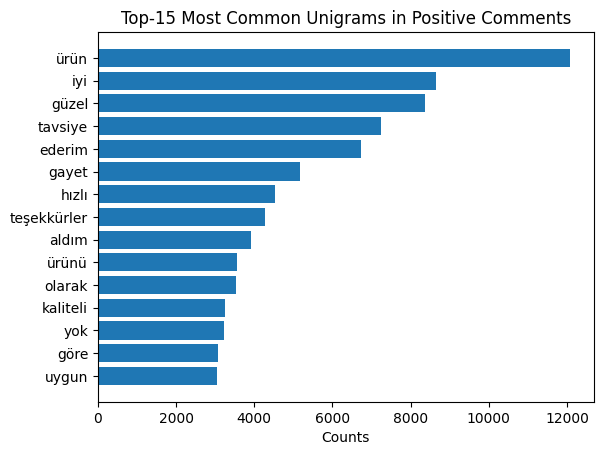

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcdefaults()
fig, ax = plt.subplots()

# Example data
ngram = top_15.keys()
y_pos = np.arange(len(ngram))
performance = top_15.values()


ax.barh(y_pos, performance, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(ngram)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Counts')
ax.set_title('Top-15 Most Common Unigrams in Positive Comments')

plt.show()

In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
from collections import Counter
import string

# Örnek veri seti (değiştirin)
# df_train = pd.read_csv('veri_seti.csv')

# Negatif sentimentler için
df_neg = df_train[df_train["sentiment"] == 0]

# Noktalama işaretleri ve stopword'leri hariç tutmak için
exclude = set(string.punctuation)

# Sadece unigramlar için
token_list = []

for i, r in df_neg.iterrows():
    text = df_neg["text"][i]
    if isinstance(text, str):  # Sadece string olanları işlemeye devam et
        text = ''.join(ch for ch in text if ch not in exclude and ch != "’")  # Noktalama işaretlerini kaldır
        tokens = word_tokenize(text)
        tokens = [tok.lower() for tok in tokens if tok not in stop_words]  # Stopword'leri kaldır
        token_list.extend(tokens)

frequencies = Counter(token_list)
frequencies_sorted = sorted(frequencies.items(), key=lambda k: k[1], reverse=True)
top_15 = dict(frequencies_sorted[0:15])

print(top_15)


{'yok': 6867, 'değil': 5693, 'ürün': 5657, 'iyi': 5614, 'kötü': 5436, 'bile': 4498, 'var': 4421, 'güzel': 3753, 'olarak': 3621, 'sonra': 3567, 'geldi': 3122, 'tavsiye': 2992, 'sadece': 2670, 'kesinlikle': 2534, 'fakat': 2493}


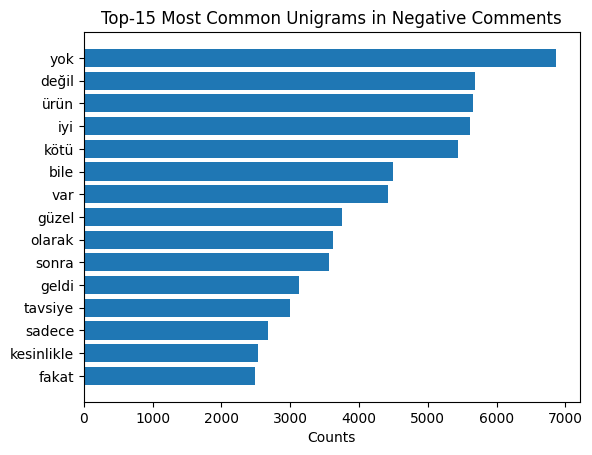

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcdefaults()
fig, ax = plt.subplots()

# Example data
ngram = top_15.keys()
y_pos = np.arange(len(ngram))
performance = top_15.values()


ax.barh(y_pos, performance, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(ngram)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Counts')
ax.set_title('Top-15 Most Common Unigrams in Negative Comments')

plt.show()

In [ ]:
from nltk.util import ngrams

token_list=[]

for i,r in df_pos.iterrows():
    text=''.join(ch for ch in df_pos["text"][i] if ch not in exclude and ch != "’") #remove punctuations from the text in order not to distort frequencies
    tokens=word_tokenize(text)
    tokens=[tok.lower() for tok in tokens if tok not in stop_words] #remove stopwords from the text in order not to distort frequencies
    token_list.extend(tokens)


bigrams=list(ngrams(token_list,2))
frequencies=Counter(bigrams)
frequencies_sorted=sorted(frequencies.items(), key=lambda k: k[1],reverse=True)
top_15=dict(frequencies_sorted[0:15])

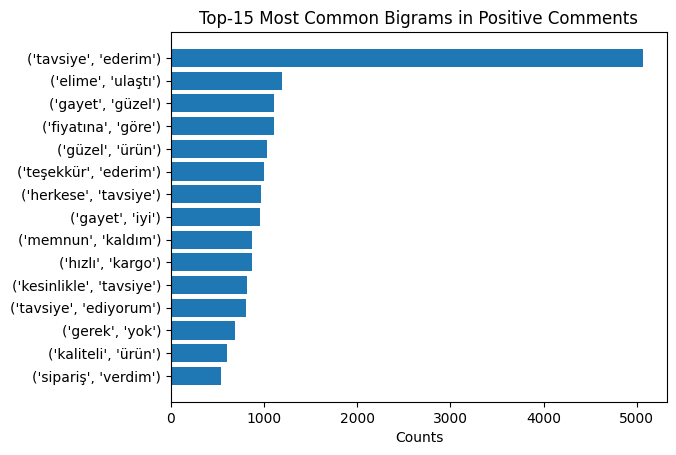

In [ ]:
plt.rcdefaults()
fig, ax = plt.subplots()

# Example data
ngram = top_15.keys()
y_pos = np.arange(len(ngram))
performance = top_15.values()


ax.barh(y_pos, performance, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(ngram)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Counts')
ax.set_title('Top-15 Most Common Bigrams in Positive Comments')

plt.show()

In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
import string

# Örnek veri seti (değiştirin)
# df_train = pd.read_csv('veri_seti.csv')

# Negatif sentimentler için
df_neg = df_train[df_train["sentiment"] == 0]

# Noktalama işaretleri ve stopword'leri hariç tutmak için
exclude = set(string.punctuation)

# Sadece unigramlar için
token_list = []

for i, r in df_neg.iterrows():
    text = df_neg["text"][i]
    if isinstance(text, str):  # Sadece string olanları işlemeye devam et
        text = ''.join(ch for ch in text if ch not in exclude and ch != "’")  # Noktalama işaretlerini kaldır
        tokens = word_tokenize(text)
        tokens = [tok.lower() for tok in tokens if tok not in stop_words]  # Stopword'leri kaldır
        token_list.extend(tokens)

bigrams = list(ngrams(token_list, 2))
frequencies = Counter(bigrams)
frequencies_sorted = sorted(frequencies.items(), key=lambda k: k[1], reverse=True)
top_15 = dict(frequencies_sorted[0:15])

print(top_15)

{('tavsiye', 'etmiyorum'): 1277, ('tavsiye', 'etmem'): 746, ('hayal', 'kırıklığı'): 528, ('kesinlikle', 'tavsiye'): 477, ('fena', 'değil'): 383, ('pişman', 'oldum'): 372, ('tavsiye', 'ederim'): 367, ('iyi', 'değil'): 346, ('memnun', 'kalmadım'): 337, ('fiyatına', 'göre'): 334, ('olmasına', 'rağmen'): 314, ('idare', 'eder'): 314, ('son', 'derece'): 306, ('zaman', 'kaybı'): 305, ('hayal', 'kırıklığına'): 302}


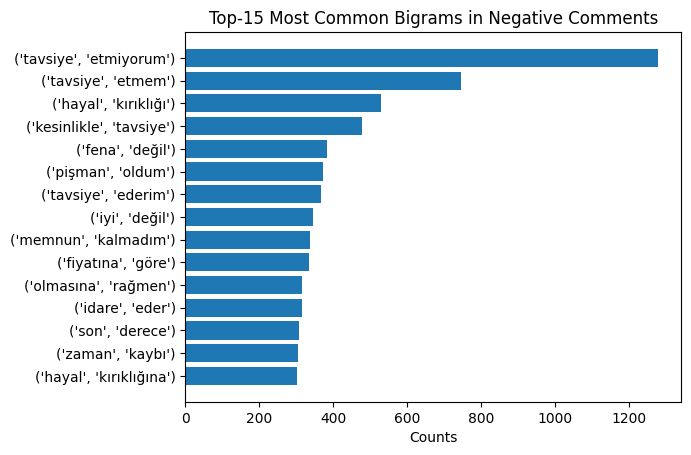

In [ ]:
plt.rcdefaults()
fig, ax = plt.subplots()

# Example data
ngram = top_15.keys()
y_pos = np.arange(len(ngram))
performance = top_15.values()


ax.barh(y_pos, performance, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(ngram)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Counts')
ax.set_title('Top-15 Most Common Bigrams in Negative Comments')

plt.show()

In [ ]:
df_train

,sentiment,text
206235,2,Albümün adını yazar Douglas Adams bulmuştur .
94254,1,bileklik çok şık duruyor ancak mesajları çalış...
86139,1,Arkadaşlar süper bir ürün kaliteli zorlamaya g...
142946,2,İlk defa bir Roma imparatoru barbarlar karşısı...
190524,2,Cenazesi Villa Ggriffone’ye defnedilmiştir .
...,...,...
119879,1,inşallah bu sessizliğin klip çektiğin içindir.
103694,1,Lezzet konusunda gerçekte çok memnuniyet duydu...
131932,1,Gercekten 24 saat boyunca sicak koruyup koruma...
146867,2,Ressamın iki modelini betimlemesi arasında büy...


### Gerekli Kütüphaneleri Yükleme

In [ ]:
# BERT tokenizer'ını yükleme

from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('dbmdz/bert-base-turkish-cased')

In [ ]:
import torch
from transformers import AutoTokenizer

def encode_data(data, tokenizer, max_length=128):
    # Verileri string haline getir ve tokenize et
    texts = data['text'].astype(str).tolist()

    # Tokenizer ile toplu olarak encode et
    encoded_dict = tokenizer.batch_encode_plus(
        texts,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoded_dict['input_ids']
    attention_masks = encoded_dict['attention_mask']

    return {
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'target': torch.tensor(data['sentiment'].values)
    }

# Eğitim ve doğrulama verilerini encode etme
train_data = encode_data(df_train, tokenizer)
val_data = encode_data(df_valid, tokenizer)


In [ ]:
import torch
from transformers import BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler

In [ ]:
def create_dataloader(dataset, batch_size, sampler):
    input_ids = torch.tensor(dataset['input_ids'].tolist())
    attention_masks = torch.tensor(dataset['attention_mask'].tolist())
    labels = torch.tensor(dataset['target'].tolist())

    data = TensorDataset(input_ids, attention_masks, labels)
    dataloader = DataLoader(data, sampler=sampler(data), batch_size=batch_size)

    return dataloader

batch_size = 16

train_dataloader = create_dataloader(train_data, batch_size, RandomSampler)
val_dataloader = create_dataloader(val_data, batch_size, SequentialSampler)

In [ ]:
### 1.3 BERT Modelini Yükleme ve Optimizasyon Ayarları
model = BertForSequenceClassification.from_pretrained(
    "dbmdz/bert-base-turkish-cased",
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False,
)

model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

epochs = 3
total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
## Adım 2: Modeli Eğitme

def train_model(model, dataloader, optimizer, scheduler):
    model.train()
    total_loss = 0

    for step, batch in enumerate(dataloader):
        batch_input_ids, batch_attention_mask, batch_labels = tuple(t.to(device) for t in batch)

        model.zero_grad()

        outputs = model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            labels=batch_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(dataloader)
    return avg_train_loss


In [ ]:
### 2.2 Değerlendirme Fonksiyonunu Tanımlama

def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    preds, true_labels = [], []

    for batch in dataloader:
        batch_input_ids, batch_attention_mask, batch_labels = tuple(t.to(device) for t in batch)

        with torch.no_grad():
            outputs = model(
                input_ids=batch_input_ids,
                attention_mask=batch_attention_mask,
                labels=batch_labels
            )

        loss = outputs.loss
        total_loss += loss.item()

        logits = outputs.logits
        preds.append(logits.detach().cpu().numpy())
        true_labels.append(batch_labels.detach().cpu().numpy())

    avg_val_loss = total_loss / len(dataloader)

    preds = np.concatenate(preds, axis=0)
    true_labels = np.concatenate(true_labels, axis=0)

    return avg_val_loss, preds, true_labels

In [ ]:

### 2.3 Model Eğitim ve Değerlendirme Döngüsü


for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss = train_model(model, train_dataloader, optimizer, scheduler)
    print(f"Training loss: {train_loss}")

    val_loss, preds, true_labels = evaluate_model(model, val_dataloader)
    print(f"Validation loss: {val_loss}")

    # Perform additional evaluation metrics if needed (e.g., accuracy, F1 score)

Epoch 1/3


In [ ]:
# Model ve veri setinin sınıf sayısını kontrol edin
num_classes = model.num_labels  # BertForSequenceClassification modelindeki sınıf sayısı

# Eğitim ve doğrulama veri setlerindeki tüm etiketleri kontrol edin
train_labels = train_dataloader.dataset.tensors[1].tolist()  # TensorDataset ise
val_labels = val_dataloader.dataset.tensors[1].tolist()      # TensorDataset ise

# Her öğenin bir liste olup olmadığını kontrol edin ve düzeltin
if isinstance(train_labels[0], list):
    train_labels = [label for sublist in train_labels for label in sublist]
if isinstance(val_labels[0], list):
    val_labels = [label for sublist in val_labels for label in sublist]

# Hedef etiketlerinin geçerli aralıkta olup olmadığını kontrol edin
invalid_train_labels = [label for label in train_labels if label >= num_classes]
invalid_val_labels = [label for label in val_labels if label >= num_classes]

if invalid_train_labels:
    print(f"Geçersiz eğitim etiketleri: {invalid_train_labels}")
if invalid_val_labels:
    print(f"Geçersiz doğrulama etiketleri: {invalid_val_labels}")

# Eğitim ve doğrulama döngüsünde hata ayıklama
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss = train_model(model, train_dataloader, optimizer, scheduler)
    print(f"Training loss: {train_loss}")

    val_loss, preds, true_labels = evaluate_model(model, val_dataloader)
    print(f"Validation loss: {val_loss}")

    # Ek değerlendirme metriklerini uygulayın (örn. doğruluk, F1 skoru)


In [ ]:
#Adım 3: Modeli Değerlendirme ve Sonuçları Yorumlama (Devam)
#3.1 Değerlendirme Metriklerini Hesaplama (Devam)

from sklearn.metrics import accuracy_score, f1_score, classification_report

def compute_metrics(pred_labels, true_labels):
    accuracy = accuracy_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels, average='weighted')
    report = classification_report(true_labels, pred_labels, target_names=["Negative", "Positive","Neutral"])
    return accuracy, f1, report

# Convert logits to predicted labels
pred_labels = np.argmax(preds, axis=1)

accuracy, f1, report = compute_metrics(pred_labels, true_labels)
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"Classification Report:\n{report}")

In [ ]:
#Adım 4: Modeli Kaydetme ve Yükleme
#4.1 Modeli Kaydetme
#Modelinizi eğittikten sonra, gelecekte kullanmak üzere kaydetmek istersiniz:

import os

output_dir = './model_save/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model saved to {output_dir}")

In [ ]:
#4.2 Modeli Yükleme
#Kaydedilmiş bir modeli yüklemek için aşağıdaki adımları takip edebilirsiniz:


from transformers import BertTokenizer, BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(output_dir)
tokenizer = BertTokenizer.from_pretrained(output_dir)

model.to(device)

In [ ]:
#Adım 5: Modeli Kullanma
#5.1 Yeni Metinleri Sınıflandırma
#Yeni metinleri sınıflandırmak için aşağıdaki fonksiyonu kullanabilirsiniz:


def predict_sentiment(text, model, tokenizer):
    inputs = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
    )

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    pred_label = torch.argmax(logits, dim=1).item()


    if pred_label == 0:
        return "Negative"
    elif pred_label == 1:
        return "Positive"
    else:
        return "Neutral"





    return "Positive" if pred_label == 1 else "Negative"

texts = [
    "Bu ürün harika!",
    "Hiç beğenmedim.",
    "Mükemmel bir deneyimdi.",
    "Youtubedan indirdim dizinin tüm bölümlerini.",
    "Bursada doğdum.",
    "Polisiye film izledik.",
    "Kedim hasta oldu.",
    "Berbattı, pişman oldum.",
    "Finalden de geçemedim.",
    "Ekmek almaya gittim."

]


# predict_sentiment fonksiyonu tanımlı olmalı
# texts listesi de tanımlı olmalı

results = []

for text in texts:
    prediction = predict_sentiment(text, model, tokenizer)
    results.append((text, prediction))

# Sonuçları yazdırma
for text, sentiment in results:
    print(f"Text: {text}\nSentiment: {sentiment}\n")


In [ ]:
#Adım 6: Modeli İnce Ayar ve Optimizasyon
#6.1 Hiperparametre Optimizasyonu
#Modelinizin performansını artırmak için hiperparametre optimizasyonu yapabilirsiniz. Örneğin, öğrenme oranı, batch boyutu, epoch sayısı gibi parametreleri ince ayar yapabilirsiniz:


# Örneğin, daha fazla epoch eğitimi
epochs = 5

# Öğrenme oranını değiştirme
optimizer = AdamW(model.parameters(), lr=3e-5, eps=1e-8)

In [ ]:
!pip install nlpaug

In [ ]:



#6.2 Veri Artırma
#Eğitim verinizi artırmak için veri artırma tekniklerini kullanabilirsiniz. Bu, modelinizin genelleme yeteneğini artırabilir:

# Örneğin, Synonym Replacement veya diğer veri artırma teknikleri
from nlpaug.augmenter.word import SynonymAug

aug = SynonymAug(aug_src='wordnet')
augmented_text = aug.augment("Bu ürün harika!")
print(augmented_text)

In [ ]:
#6.3 Modelin İnce Ayarlarını Yapma
#BERT’in bazı katmanlarının serbest bırakılması veya dondurulması gibi daha ileri düzey tekniklerle model performansını artırabilirsiniz:

# İlk birkaç katmanı dondurmak
for param in model.bert.parameters():
    param.requires_grad = False

# Sadece son katmanları eğitmek
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

In [ ]:
#Adım 7: Modeli Dağıtma
#7.1 Modeli API ile Sunma
#Flask veya FastAPI gibi bir web framework kullanarak modelinizi bir API üzerinden sunabilirsiniz:


from flask import Flask, request, jsonify

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Model ağırlıklarını kaydet
model.save_weights('/content/drive/MyDrive/model_weights.h5')

print("Model ağırlıkları kaydedildi!")